In [1]:
import matplotlib.pyplot as plt
import numpy as np

import torchvision
import torchvision.utils as vutils
import torch
from torchvision import datasets, transforms



/Users/amirmhd/anaconda3/envs/DL/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'dlopen(/Users/amirmhd/anaconda3/envs/DL/lib/python3.10/site-packages/torchvision/image.so, 0x0006): Symbol not found: __ZN3c1017RegisterOperatorsD1Ev
  Referenced from: <5AA8DD3D-A2CC-31CA-8060-88B4E9C18B09> /Users/amirmhd/anaconda3/envs/DL/lib/python3.10/site-packages/torchvision/image.so
  Expected in:     <3E74E253-B679-3D99-83AD-457697D811DA> /Users/amirmhd/anaconda3/envs/DL/lib/python3.10/site-packages/torch/lib/libtorch_cpu.dylib'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Failed to download (trying next):
HTTP Error 404: Not Found



100%|███████████████████████████████████████████████████████████████████| 9912422/9912422 [00:00<00:00, 21909109.05it/s]


Extracting MNIST_data/MNIST/raw/train-images-idx3-ubyte.gz to MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|█████████████████████████████████████████████████████████████████████████| 28881/28881 [00:00<00:00, 989953.78it/s]

Extracting MNIST_data/MNIST/raw/train-labels-idx1-ubyte.gz to MNIST_data/MNIST/raw



Failed to download (trying next):
HTTP Error 404: Not Found



100%|████████████████████████████████████████████████████████████████████| 1648877/1648877 [00:00<00:00, 4797611.56it/s]


Extracting MNIST_data/MNIST/raw/t10k-images-idx3-ubyte.gz to MNIST_data/MNIST/raw

Failed to download (trying next):
HTTP Error 404: Not Found



100%|██████████████████████████████████████████████████████████████████████████| 4542/4542 [00:00<00:00, 1201926.11it/s]

Extracting MNIST_data/MNIST/raw/t10k-labels-idx1-ubyte.gz to MNIST_data/MNIST/raw



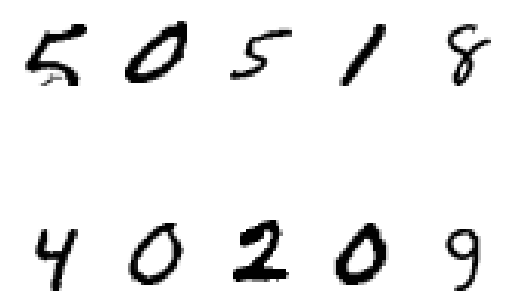

In [2]:
transform = transforms.Compose([transforms.ToTensor(),
                              transforms.Normalize((0.1307,), (0.3081,))])

trainset = datasets.MNIST('MNIST_data/', download=True, train=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)


testset = datasets.MNIST('MNIST_data/', download=True, train=False, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=64, shuffle=True)



dataiter = iter(trainloader)
images, labels = next(dataiter)

figure = plt.figure()
num_of_images = 10
for index in range(1, num_of_images + 1):
    plt.subplot(2, 5, index)
    plt.axis('off')
    plt.imshow(images[index].numpy().squeeze(), cmap='gray_r')

In [3]:
images[0].shape

torch.Size([1, 28, 28])

In [4]:
import torch
import torch.nn as nn
class Gen(nn.Module):
  def __init__(self, embedding_dim):
    super().__init__()

    self.linear_1 = nn.Linear(embedding_dim, 7 * 7 * 64)
    self.non_linear = nn.LeakyReLU(0.1)
  # here I will have B 64 7 7  # 64 is channel dim, we start with high channel dim and gradually decrease it
    self.t_conv1 = nn.ConvTranspose2d(in_channels=64, out_channels=32, kernel_size=4, padding=1, stride=2)
  # here I will have B 32 14 14
    self.bn1 = nn.BatchNorm2d(32)

    self.t_conv2 = nn.ConvTranspose2d(in_channels=32, out_channels=1, kernel_size=4, stride=2, padding=1)
    self.tanh_ = nn.Tanh()
  def forward(self, z):

    out = self.linear_1(z)
    out = self.non_linear(out)
    out = out.reshape(out.shape[0], 64, 7 , 7)
    out = self.t_conv1 (out)
    out = self.bn1(out)
    out = self.non_linear(out)
    out = self.t_conv2(out)
    # out = self.tanh_(out)
    return out




In [5]:
class Dis(nn.Module):
    def __init__(self):
        super().__init__()
        # input dim = 1 28 28
        self.cnn_1 = nn.Conv2d(in_channels=1, out_channels=4, kernel_size=4, padding=1)  # 4 28 28
        self.max_pool_1 = nn.MaxPool2d(kernel_size=2, stride=2)  # 4 14 14
        self.cnn_2 = nn.Conv2d(in_channels=4, out_channels=16, kernel_size=4, padding=1)  # 16 14 14
        self.max_pool_2 = nn.MaxPool2d(kernel_size=2, stride=2)  # 16 7 7
        self.cnn_3 = nn.Conv2d(in_channels=16, out_channels=64, kernel_size=3, padding=1)  # 64 7 7
        self.max_pool_3 = nn.MaxPool2d(kernel_size=2, stride=2)  # 64 3 3
        self.flatten = nn.Flatten()  # 64 * 3 * 3 = 576
        self.linear = nn.Linear(576, 1)  # Final classification (real/fake)
        self.non_linear = nn.LeakyReLU(0.2)
        self.output_activation = nn.Sigmoid()  # Output between 0-1
        self.dropout = nn.Dropout(0.15)
    def forward(self, x):
        # x shape: [batch_size, 1, 28, 28]
        x = self.cnn_1(x)

        x = self.dropout(x)
        x = self.non_linear(x)
        x = self.max_pool_1(x)

        x = self.cnn_2(x)
        x = self.dropout(x)

        x = self.non_linear(x)
        x = self.max_pool_2(x)

        x = self.cnn_3(x)
        x = self.dropout(x)

        x = self.non_linear(x)
        x = self.max_pool_3(x)

        x = self.flatten(x)
        x = self.linear(x)
        x = self.dropout(x)

        x = self.output_activation(x)

        return x




In [8]:
device = torch.device('mps')


In [ ]:
epochs = 50
embedding_dim = 64
gen_ = Gen(embedding_dim=embedding_dim).to(device)
dis_ = Dis().to(device)
optim_D = torch.optim.Adam(lr=0.0002, betas=(0.5, 0.999), params=dis_.parameters())
optim_G = torch.optim.Adam(lr=0.001, betas=(0.5, 0.999), params=gen_.parameters())
fixed_noise = torch.randn(64, embedding_dim).to(device)
img_list = []


loss_bce = torch.nn.BCELoss().to(device)

g_losses = []
d_losses = []

for epoch in range(epochs):
    epoch_g_loss = 0.0
    epoch_d_loss = 0.0
    batches = 0
    for i, (x_batch, y_batch) in enumerate(trainloader):
        batch_size = y_batch.shape[0]
        y_real = torch.ones(batch_size, 1).to(device) * 0.9
        y_fake = torch.zeros(batch_size, 1).to(device)
        x_batch = x_batch.to(device)

        #############
        #############
        ## Train Disc

        z = torch.randn(batch_size, embedding_dim).to(device)

        x_hat = gen_(z).detach()
        y_hat_fake = dis_(x_hat)
        loss_fake = loss_bce(y_hat_fake, y_fake)
        y_hat_real = dis_(x_batch)
        loss_real = loss_bce(y_hat_real, y_real)

        ## Total loss
        loss_total = (loss_real + loss_fake) / 2

        # Updating dis
        optim_D.zero_grad()
        loss_total.backward()
        optim_D.step()

        ###########
        ###########
        ## Train Generator
        for j in range(0, 30):
          # z = torch.randn(batch_size, embedding_dim).to(device)

          x_hat = gen_(z)
          # generator needs to predict these as real!
          y_hat_gen = dis_(x_hat)

          loss_gen = -torch.mean(torch.log(y_hat_gen))  # Non-saturating loss

          optim_G.zero_grad()
          loss_gen.backward()
          optim_G.step()
        epoch_d_loss += loss_total.item()
        epoch_g_loss += loss_gen.item()
        batches += 1

        # Print progress within epoch
        if i % 100 == 0:
            d_real_acc = (y_hat_real > 0.5).float().mean().item() * 100
            d_fake_acc = (y_hat_fake < 0.5).float().mean().item() * 100
            g_fool_acc = (y_hat_gen > 0.5).float().mean().item() * 100

            print(f"[{epoch}/{epochs}][{i}/{len(trainloader)}] "
                  f"D_loss: {loss_total.item():.4f}, G_loss: {loss_gen.item():.4f} | "
                  f"D real acc: {d_real_acc:.1f}%, D fake acc: {d_fake_acc:.1f}%, G fool acc: {g_fool_acc:.1f}%")

    # Track average epoch losses
    avg_d_loss = epoch_d_loss / batches
    avg_g_loss = epoch_g_loss / batches
    g_losses.append(avg_g_loss)
    d_losses.append(avg_d_loss)

    # Print epoch summary
    print(f"Epoch {epoch}/{epochs} complete | Avg D_loss: {avg_d_loss:.4f}, Avg G_loss: {avg_g_loss:.4f}")

    with torch.no_grad():

    # Generate and display sample images at the end of each epoch
        fake = gen_(fixed_noise).detach().cpu()
        img_list.append(vutils.make_grid(fake[:16], padding=2, normalize=True))

        # Display the latest generated images
        if epoch % 2 == 0 or epoch == epochs-1:
            plt.figure(figsize=(8, 8))
            plt.axis("off")
            plt.title(f"Generated Images (Epoch {epoch})")
            plt.imshow(np.transpose(img_list[-1], (1, 2, 0)))
            plt.show()

print("Training complete!")

[0/50][0/938] D_loss: 0.7064, G_loss: 0.3263 | D real acc: 18.8%, D fake acc: 29.7%, G fool acc: 89.1%
[0/50][100/938] D_loss: 0.7540, G_loss: 0.7122 | D real acc: 0.0%, D fake acc: 76.6%, G fool acc: 10.9%
[0/50][200/938] D_loss: 0.7283, G_loss: 0.7344 | D real acc: 0.0%, D fake acc: 79.7%, G fool acc: 0.0%
[0/50][300/938] D_loss: 0.7178, G_loss: 0.7407 | D real acc: 0.0%, D fake acc: 85.9%, G fool acc: 0.0%
[0/50][400/938] D_loss: 0.7069, G_loss: 0.7437 | D real acc: 0.0%, D fake acc: 85.9%, G fool acc: 0.0%


Observation: Generator will be too weak infront of the discriminator. I tried to increase the iterations that I train the discriminator but it seems like it doesnt matter!

things I tried: Tried to weaker the discriminator... I added drop out with very large rate. Added label smoothing with very high amount